In [86]:
import pandas as pd
import numpy as np
import os

In [87]:
from sklearn.model_selection import train_test_split


from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.feature_selection import SelectFromModel

import lightgbm as lgbm


In [150]:
def removeOutliers(df):
    percentile90 = df['soldPrice'].quantile(0.90)
    percentile10 = df['soldPrice'].quantile(0.10)

    iqr = percentile90 - percentile10

    upper_limit = percentile90 + 3 * iqr
    lower_limit = percentile10 - 3 * iqr

    # df[df['soldPrice'] > upper_limit]
    # df[df['soldPrice'] < lower_limit]

    df = df[df['soldPrice'] < upper_limit]
    df = df[df['soldPrice'] > lower_limit]

    return df

In [151]:
data = pd.read_csv(os.getcwd()+"\\data\\data.csv")

In [152]:
data = removeOutliers(data)

In [153]:
data.shape

(319971, 1330)

Split onto train/test 

In [199]:
x, y = data.drop(['soldPrice', 'listPrice'], axis = 1), data['soldPrice']

In [200]:
import re
x = x.rename(columns = lambda z: re.sub('[^A-Za-z0-9_]+', '', z))

In [156]:
x.columns

Index(['listPrice', 'latitude', 'longitude', 'DOM', 'avg_sqft', 'ppsqft',
       'bathtobed_ratio', 'listPrice_by_area', 'listPrice_by_city',
       'class_CondoProperty',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1329)

In [201]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

print('Shape of x_train: ' + str(x_train.shape))
print('Shape of y_train: ' + str(y_train.shape))
print('Shape of x_test: ' + str(x_test.shape))
print('Shape of y_test: ' + str(y_test.shape))

Shape of x_train: (223979, 1328)
Shape of y_train: (223979,)
Shape of x_test: (95992, 1328)
Shape of y_test: (95992,)


In [ ]:
x_train.columns

Index(['listPrice', 'latitude', 'longitude', 'DOM', 'avg_sqft', 'ppsqft',
       'bathtobed_ratio', 'listPrice_by_area', 'listPrice_by_city',
       'class_CondoProperty',
       ...
       'style_BungalowRaised', 'style_IndustrialLoft', 'style_Loft',
       'style_MultiLevel', 'style_Other', 'style_Sidesplit3',
       'style_Sidesplit4', 'style_Sidesplit5', 'style_StackedTownhse',
       'style_WarehouseLoft'],
      dtype='object', length=1329)

In [202]:
#Define XGBoost parameters tree_method = 'gpu_hist'
base_regressor = lgbm.LGBMRegressor(learning_rate = 0.3,random_state=0)

#Get top 100 features using XGBoost
select_feat = SelectFromModel(base_regressor,threshold=-np.inf,max_features=25).fit(x_train,y_train)

In [206]:
#Get indices of top 100 features 
feat_index = select_feat.get_support()

#Rename the columns of training and test sets to include column names of top 100 features
train_x = pd.DataFrame(x_train, columns = x_train.columns[feat_index])
test_x = pd.DataFrame(x_test, columns= x_test.columns[feat_index])


#Print the top 100 features
for col in x_train.columns[feat_index]:
    print(col)

latitude
longitude
DOM
avg_sqft
ppsqft
bathtobed_ratio
listPrice_by_area
listPrice_by_city
area_Toronto
district_TorontoC02
neighborhood_Eastlake
neighborhood_RuralInnisfil
numBathrooms_1
numBathrooms_2
numBathrooms_3
numBathrooms_4
numBathrooms_5
numBedrooms_1
numBedrooms_2
numBedrooms_3
numBedrooms_4
numBedrooms_5
style_2Storey
style_Apartment
style_Bungalow


<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

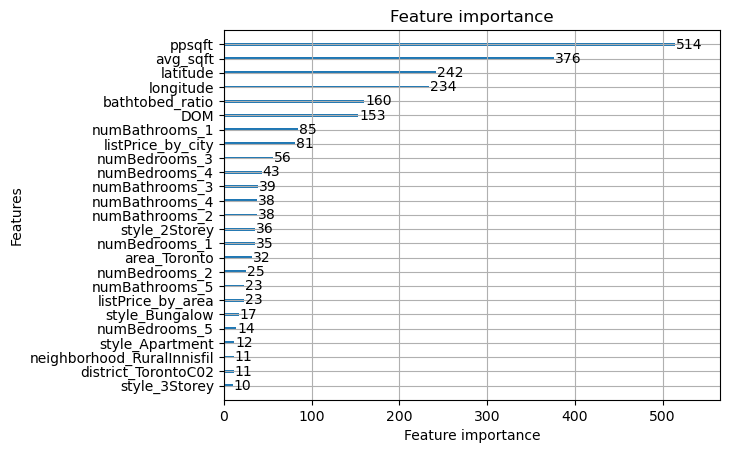

In [204]:
lgbm.plot_importance(base_regressor.fit(x_train,y_train), max_num_features = 25)

In [207]:
train_x

,latitude,longitude,DOM,avg_sqft,ppsqft,bathtobed_ratio,listPrice_by_area,listPrice_by_city,area_Toronto,district_TorontoC02,...,numBathrooms_4,numBathrooms_5,numBedrooms_1,numBedrooms_2,numBedrooms_3,numBedrooms_4,numBedrooms_5,style_2Storey,style_Apartment,style_Bungalow
64888,44.068829,-79.499980,4,NaN,NaN,1.000000,2602.068714,2784.416058,0,0,...,0,0,0,0,1,0,0,1,0,0
251117,43.657376,-79.374108,3,649.5,4.612779,0.500000,2551.974056,2551.974056,1,0,...,0,0,0,1,0,0,0,0,1,0
251826,43.577723,-79.637644,20,2750.0,1.636364,1.000000,2549.302092,2565.449606,0,0,...,1,0,0,0,0,1,0,1,0,0
224031,44.059669,-79.467921,42,NaN,NaN,0.333333,2602.068714,2404.587468,0,0,...,0,0,0,0,1,0,0,0,0,1
248968,44.447119,-79.730231,27,3250.0,2.461538,1.250000,2501.360395,2888.071429,0,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120115,43.646834,-79.392399,58,249.5,7.014028,1.000000,2551.974056,2551.974056,1,0,...,0,0,1,0,0,0,0,0,1,0
259771,43.501462,-79.832501,17,NaN,NaN,1.500000,2988.066213,2612.904592,0,0,...,0,0,0,1,0,0,0,0,0,0
132186,43.651533,-79.375331,65,549.5,3.412193,1.000000,2551.974056,2551.974056,1,0,...,0,0,1,0,0,0,0,0,1,0
147153,43.740041,-79.310565,12,NaN,NaN,0.750000,2551.974056,2551.974056,1,0,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
#LightGBM parameters
params = {
        'colsample_bytree': [0.5, 0.75, 1],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.25, 0.5, 1.0],
        'max_depth': [5, 7, 9, 11],
        'num_leaves': [15,30,45],
        'reg_lambda': [0.01, 0.5, 0.1],
        'min_child_samples': [10,20,30],
        }

In [208]:
#Define XGBoost base model 
lgbm_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')

grid_search = GridSearchCV(lgbm_model, params, cv=5,verbose=3)
grid_search.fit(train_x, y_train)

Fitting 5 folds for each of 2916 candidates, totalling 14580 fits


KeyboardInterrupt: 

In [ ]:
#Get results of gridsearch 
grid_results_df = pd.DataFrame(grid_search.cv_results_)
#Save to csv
grid_results_df.to_csv("GridSearch_CV_results.csv", index = False)

In [93]:
grid_results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_min_child_samples,param_num_leaves,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.911871,2.902728,0.108499,0.066214,0.5,0.01,5,10,15,0.01,0.25,"{'colsample_bytree': 0.5, 'learning_rate': 0.0...",0.685914,0.672614,0.711594,0.696748,0.647949,0.682964,0.021687,2909
1,1.465655,0.058424,0.082075,0.011792,0.5,0.01,5,10,15,0.01,0.5,"{'colsample_bytree': 0.5, 'learning_rate': 0.0...",0.685914,0.672614,0.711594,0.696748,0.647949,0.682964,0.021687,2910
2,1.492625,0.046537,0.081074,0.005181,0.5,0.01,5,10,15,0.01,1.0,"{'colsample_bytree': 0.5, 'learning_rate': 0.0...",0.685914,0.672614,0.711594,0.696748,0.647949,0.682964,0.021687,2908
3,1.494627,0.021559,0.076069,0.006788,0.5,0.01,5,10,15,0.5,0.25,"{'colsample_bytree': 0.5, 'learning_rate': 0.0...",0.684483,0.672498,0.710237,0.696257,0.645408,0.681777,0.022071,2916
4,1.520704,0.093424,0.080473,0.007665,0.5,0.01,5,10,15,0.5,0.5,"{'colsample_bytree': 0.5, 'learning_rate': 0.0...",0.684483,0.672498,0.710237,0.696257,0.645408,0.681777,0.022071,2914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,2.734933,0.313019,0.118531,0.016484,1,0.2,11,30,45,0.5,0.5,"{'colsample_bytree': 1, 'learning_rate': 0.2, ...",0.943724,0.926301,0.961731,0.939943,0.898500,0.934040,0.021064,854
2912,3.218676,0.202820,0.123648,0.021192,1,0.2,11,30,45,0.5,1.0,"{'colsample_bytree': 1, 'learning_rate': 0.2, ...",0.943723,0.926301,0.961758,0.939934,0.898499,0.934043,0.021071,849
2913,2.597651,0.178539,0.125314,0.009462,1,0.2,11,30,45,0.1,0.25,"{'colsample_bytree': 1, 'learning_rate': 0.2, ...",0.944053,0.925464,0.961372,0.940124,0.899608,0.934124,0.020704,796
2914,2.861289,0.625051,0.120109,0.020444,1,0.2,11,30,45,0.1,0.5,"{'colsample_bytree': 1, 'learning_rate': 0.2, ...",0.944052,0.925464,0.961369,0.940128,0.899611,0.934125,0.020703,795


In [ ]:
grid_results_df.sort_values(by=['rank_test_score']).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_min_child_samples,param_num_leaves,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2272,1.190682,0.037390,0.102493,0.043970,1,0.1,5,10,15,0.5,0.5,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.951087,0.928749,0.966153,0.941370,0.911769,0.939825,0.018613,1
2271,1.228517,0.048478,0.123912,0.042292,1,0.1,5,10,15,0.5,0.25,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.951087,0.928757,0.966153,0.941370,0.911754,0.939824,0.018616,2
2273,1.214504,0.031964,0.118908,0.036107,1,0.1,5,10,15,0.5,1.0,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.951087,0.928750,0.966153,0.941363,0.911754,0.939821,0.018617,3
2274,1.212903,0.029184,0.094486,0.006474,1,0.1,5,10,15,0.1,0.25,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.951284,0.928286,0.965342,0.941517,0.911958,0.939677,0.018411,4
2275,1.211301,0.014441,0.086679,0.003385,1,0.1,5,10,15,0.1,0.5,"{'colsample_bytree': 1, 'learning_rate': 0.1, ...",0.951284,0.928279,0.965341,0.941517,0.911954,0.939675,0.018413,5


In [209]:
best_model = lgbm.LGBMRegressor(n_estimators=100, device = 'gpu')
best_model.set_params(**grid_results_df.sort_values(by=['rank_test_score'])['params'].values[0])

best_model = best_model.fit(train_x, y_train)
best_model

LGBMRegressor(colsample_bytree=1, device='gpu', max_depth=5,
              min_child_samples=10, num_leaves=15, reg_lambda=0.5,
              subsample=0.5)

In [ ]:
best_model.booster_.trees_to_dataframe()

,tree_index,node_depth,node_index,left_child,right_child,parent_index,split_feature,split_gain,threshold,decision_type,missing_direction,missing_type,value,weight,count
0,0,1,0-S0,0-S2,0-S1,None,listPrice,9.533360e+10,3152.5,<=,left,None,2564.840000,0.0,224539
1,0,2,0-S2,0-S6,0-S5,0-S0,listPrice,2.539600e+10,2252.5,<=,left,None,2536.020000,187787.0,187787
2,0,3,0-S6,0-S12,0-S13,0-S2,listPrice,4.174920e+09,1827.0,<=,left,None,2498.020000,90824.0,90824
3,0,4,0-S12,0-L0,0-L13,0-S6,listPrice,8.729590e+08,1505.0,<=,left,None,2468.590000,31495.0,31495
4,0,5,0-L0,None,None,0-S12,None,NaN,NaN,None,None,None,2442.361402,9046.0,9046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2639,99,5,99-L8,None,None,99-S7,None,NaN,NaN,None,None,None,-21.996680,10.0,10
2640,99,3,99-S6,99-L2,99-L7,99-S1,DOM,1.965900e+05,29.5,<=,left,None,-20.679400,22.0,22
2641,99,4,99-L2,None,None,99-S6,None,NaN,NaN,None,None,None,-29.142566,12.0,12
2642,99,4,99-L7,None,None,99-S6,None,NaN,NaN,None,None,None,-9.619365,10.0,10


In [210]:
y_pred = best_model.predict(test_x)

In [211]:
metrics.mean_absolute_error(y_test, y_pred)

159.5630766941232

In [212]:
metrics.r2_score(y_test, y_pred)

0.8694293579817631

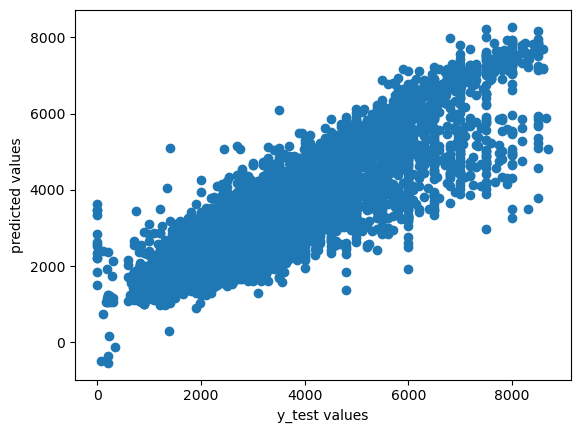

In [214]:
import matplotlib.pyplot as plt

plt.scatter(x = y_test.values,y =  y_pred)
plt.xlabel("y_test values")
plt.ylabel("predicted values")
plt.show()

